# Exercise 4: Classification with Logistic Regression

```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activities work
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_04/exercise_04_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_04/exercise_04_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps the two
embedded activities for links back to this page.
```

## What this notebook covers

This is Exercise 4 of *Machine Learning for Neuroscience*. Exercises 2-3
used ABIDE's rich neuroimaging table to ask a **regression** question:
predicting a participant's age from cortical structure. Autism diagnosis --
ABIDE's own central scientific question -- has not yet been addressed. This
practice builds one **classifier**: predicting autism diagnosis from the
same brain measurements, tested on participants it has not seen.

In this notebook you will:

1. look at the ABIDE data used for classifying autism diagnosis;
2. turn a logistic-regression score into a probability;
3. build one logistic-regression classifier and test it on participants it
   has not seen;
4. read a confusion matrix, and compute accuracy, sensitivity, and
   specificity from it, plus an ROC curve and AUC;
5. use a browser activity to explore how changing the decision threshold
   changes those measures;
6. see why accuracy can be misleading when one diagnosis group is much
   larger than the other.

**Prerequisites:** Exercise 2's train/test workflow, `StandardScaler`,
`Pipeline` / `fit` / `predict` in scikit-learn, and testing a model on
held-out participants (Exercises 2-3's comparison of correct and misleading
evaluation methods, including resubstitution -- this notebook does not
repeat that demonstration a third time).


## 1. The ABIDE classification data

ABIDE's own central scientific distinction is **autism diagnosis**.
Exercises 2-3 used this same rich dataset to ask a regression question about
age instead; this notebook returns to ABIDE's original question. The table
itself is unchanged: the same 1004-participant data table, one row per
participant, with the same 360 bilateral cortical-thickness (`fsCT`) columns
used throughout Exercises 2-3.


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. Nothing
# here is repository-specific. Same data and provenance as Exercises 2-3.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
)

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
print(f"data table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")


data table: 1004 participants x 1446 columns


In [2]:
# group: 1 = autism, 2 = control -- native to this table, no join needed.
# A compact preview plus class counts and a missingness statement.
preview_cols = ["subject", "site", "group", "age", "sex", "fsCT_L_46_ROI"]
display(model_df[preview_cols].head(3))

class_counts = model_df["group"].value_counts().sort_index()
n_autism = int(class_counts.get(1.0, 0))
n_control = int(class_counts.get(2.0, 0))
n_missing_group = int(model_df["group"].isna().sum())
n_dup_subjects = int(model_df["subject"].duplicated().sum())
print(f"class counts: {n_autism} autism (group=1), {n_control} control (group=2)")
print(f"missing diagnosis: {n_missing_group} of {len(model_df)} participants")
print(f"duplicate participant ids: {n_dup_subjects}")


,subject,site,group,age,sex,fsCT_L_46_ROI
0,29293,ABIDEII-KKI_1,1.0,8.893151,2.0,2.366
1,28997,ABIDEII-OHSU_1,1.0,12.000000,2.0,2.579
2,28845,ABIDEII-GU_1,2.0,8.390000,1.0,2.690


class counts: 463 autism (group=1), 541 control (group=2)
missing diagnosis: 0 of 1004 participants
duplicate participant ids: 0


```{admonition} Think first
:class: think-first
For this table, what does one row represent, and what does the target for
this notebook represent? (They are not the same kind of thing as Exercise
2's outcome.)
```

```{dropdown} Check your reasoning
One row is still one participant -- unchanged from Exercises 1-3. The target
for this notebook is `group`, recoded to a binary autism/control label: it
is a **categorical diagnosis**, not a continuous measurement like `age`. That
is the difference between this notebook's task (classification) and
Exercise 2-3's task (regression): the same rows and the same brain columns,
a different kind of outcome.
```

## 2. From a linear score to a probability

Logistic regression starts exactly like linear regression: a weighted sum of
the standardized features plus an intercept, $z = w \cdot x + b$. Unlike
linear regression, that score $z$ is not the prediction itself -- it is
passed through the **sigmoid** function to become a probability between 0
and 1:

$$P(Y=1\mid X)=\frac{1}{1+e^{-z}}$$

In plain language:

1. Logistic regression calculates a weighted linear score, exactly like
   linear regression's $z$.
2. The sigmoid squashes that score into a probability between 0 and 1.
3. A **decision threshold**, commonly 0.50, converts the probability into a
   predicted class: probability at or above the threshold predicts autism,
   below it predicts control.

This notebook does not derive the loss function logistic regression
minimizes to find $w$ and $b$ -- only what the fitted model outputs and how
that output becomes a class label.


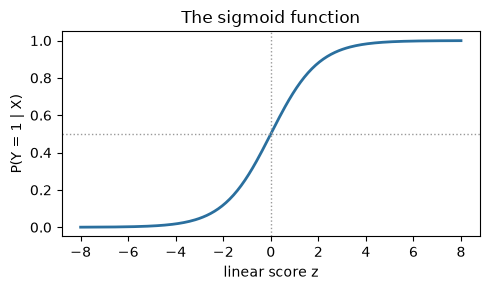

In [3]:
# A small, clean sigmoid figure: any real-valued score maps to (0, 1).
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z_grid = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(z_grid, sigmoid(z_grid), color="#2a6f9e", lw=2)
ax.axhline(0.5, color="0.6", lw=1, ls=":")
ax.axvline(0, color="0.6", lw=1, ls=":")
ax.set_xlabel("linear score z"); ax.set_ylabel("P(Y = 1 | X)")
ax.set_title("The sigmoid function")
plt.tight_layout(); plt.show()


```{admonition} Think first
:class: think-first
If two participants receive autism probabilities of 0.48 and 0.52, must
their underlying model evidence be very different merely because their
predicted labels differ?
```

```{dropdown} Check your reasoning
No. At the default 0.50 threshold, 0.48 predicts control and 0.52 predicts
autism -- opposite labels -- but the two probabilities themselves are nearly
identical. The sigmoid is continuous: a tiny change in the linear score
crossing the threshold flips the label while barely changing the model's
actual evidence. A predicted label is a summary of a probability, and near a
threshold that summary can be almost arbitrary.
```

## 3. One logistic-regression model

**Target:** diagnosis (`group`, recoded autism=1 / control=0). **Positive
class:** autism. **Negative class:** control. **Predictors:** the exact same
360 bilateral cortical-thickness (`fsCT`) columns used throughout Exercises
2-3 -- no diagnosis-derived field, participant id, age, sex, site, or
behavioural score is a predictor. **Split:** a participant-level, stratified
75/25 train/test split, `random_state=42` -- the same fixed
random seed used throughout this course, chosen before this split was ever scored. **Model:**
`StandardScaler` (fit on training rows only) then `LogisticRegression`
using `C = 1.0` for this example, fit on the training participants and
evaluated once on the test participants. A later lesson introduces
systematic methods for selecting `C`.


In [4]:
# The full set of 360 cortical-thickness columns -- identical recipe and
# code to Exercises 2-3's Section 2.
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)           # brain-only
assert "group" not in FEATURES                                # no target leakage
print(f"{len(FEATURES)} features, e.g. {FEATURES[:3]}")


360 features, e.g. ['fsCT_L_V1_ROI', 'fsCT_L_MST_ROI', 'fsCT_L_V6_ROI']


In [5]:
# Brain-only X and binary target y. group has no missing values (checked
# above), so every one of the 1004 participants is usable here -- unlike
# Exercise 2's FIQ target, this notebook needs no row filtering.
X = model_df[FEATURES].to_numpy(float)
y = (model_df["group"] == 1).astype(int).to_numpy()   # 1 = autism, 0 = control

# One fixed, reproducible, participant-level split, stratified by y itself
# (the diagnosis label) -- not by a covariate, since y IS diagnosis here.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"n_train = {len(y_train)}   n_test = {len(y_test)}   n_features = {X.shape[1]}")
print(f"train autism rate = {y_train.mean():.3f}   test autism rate = {y_test.mean():.3f}")


n_train = 753   n_test = 251   n_features = 360
train autism rate = 0.461   test autism rate = 0.462


### Choosing C for this example

In this introductory exercise, we choose one model setting in advance, fit
the model using the training participants, and evaluate it on the test
participants. A later lesson will introduce systematic methods for
selecting model settings.

```python
C_EXAMPLE = 1.0
```

This is simply the value used for this worked example, chosen before the
held-out result below is computed. It is not optimized, tuned, or chosen
because it performed best.


In [6]:
C_EXAMPLE = 1.0


In [7]:
# Explicit scaling, written out: fit_transform LEARNS the training columns'
# means/standard deviations; transform then applies those SAME already-
# learned values to the test data -- the scaler is never fitted on the test
# set, exactly like Exercise 2's Section 2. Uses C = 1.0, the value chosen
# for this example, from above.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

explicit_model = LogisticRegression(C=C_EXAMPLE, max_iter=5000)
explicit_model.fit(X_train_scaled, y_train);


As in Exercise 2, `scikit-learn`'s `make_pipeline` bundles the scaler and the
classifier into one object so `.fit()` always scales before fitting and
`.predict()` / `.predict_proba()` always reuse the scaler already learned
from training data. This is the model used for the rest of this notebook.


In [8]:
# The pipeline shortcut: same two steps, bundled, with C = 1.0, the value
# chosen for this example. This is the model used for the rest of this notebook.
model = make_pipeline(StandardScaler(), LogisticRegression(C=C_EXAMPLE, max_iter=5000))
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
assert np.array_equal(y_pred, explicit_model.predict(X_test_scaled))   # identical to the explicit version above
print("predicted labels and probabilities computed for the held-out test set.")
print("Every metric below uses only these 251 test participants -- none of them were used to fit the model.")


predicted labels and probabilities computed for the held-out test set.
Every metric below uses only these 251 test participants -- none of them were used to fit the model.


## 4. Classification outcomes and metrics

A confusion matrix counts every combination of actual and predicted
diagnosis on the held-out test set. Rows are the **actual** diagnosis,
columns are the **predicted** diagnosis, and autism is the positive class:

| Outcome | Interpretation |
|---|---|
| True negative | A control participant is classified as control. |
| False positive | A control participant is classified as autistic. |
| False negative | An autistic participant is classified as control. |
| True positive | An autistic participant is classified as autistic. |

**Accuracy** is the proportion of all test participants classified
correctly:

$$\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN}$$

Two more specific rates matter as much as accuracy, especially under class
imbalance (Section 6):

- **Sensitivity** (recall): the proportion of *actually autistic*
  participants the model detects, $TP/(TP+FN)$;
- **Specificity**: the proportion of *actually control* participants the
  model correctly identifies, $TN/(TN+FP)$.

A single threshold gives one confusion matrix. The **ROC curve** plots
sensitivity against the false-positive rate ($1-\mathrm{specificity}$) as
the threshold sweeps across every possible value, and **AUC** (area under
that curve) summarizes ranking performance independent of any one threshold:
0.5 is chance-level ranking, 1.0 is perfect ranking.


In [9]:
# The test-set confusion matrix, accuracy, sensitivity, specificity,
# ROC curve, and AUC -- every number below uses only the 251 test
# participants excluded from fitting.
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
accuracy = accuracy_score(y_test, y_pred)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_test, y_proba)

cm_labels = np.array([
    [f"TN = {tn}", f"FP = {fp}"],
    [f"FN = {fn}", f"TP = {tp}"],
])
cm_table = pd.DataFrame(
    cm_labels, index=["actual control", "actual autism"], columns=["predicted control", "predicted autism"]
)
display(cm_table)
print(f"accuracy    = {accuracy:.3f}")
print(f"sensitivity = {sensitivity:.3f}  (proportion of autistic participants detected)")
print(f"specificity = {specificity:.3f}  (proportion of control participants correctly identified)")
print(f"AUC         = {auc:.3f}  (0.5 = chance-level ranking, 1.0 = perfect ranking)")


,predicted control,predicted autism
actual control,TN = 75,FP = 60
actual autism,FN = 54,TP = 62


accuracy    = 0.546
sensitivity = 0.534  (proportion of autistic participants detected)
specificity = 0.556  (proportion of control participants correctly identified)
AUC         = 0.569  (0.5 = chance-level ranking, 1.0 = perfect ranking)


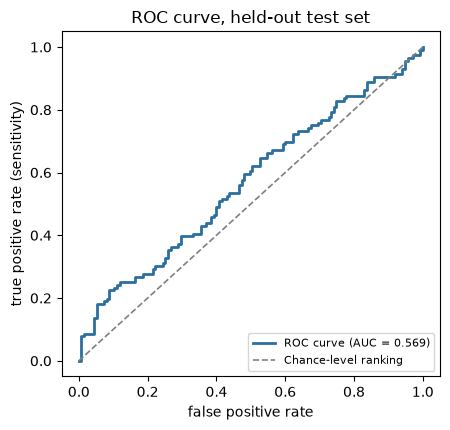

In [10]:
# ROC curve.
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot(fpr, tpr, color="#2a6f9e", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="0.5", lw=1.2, label="Chance-level ranking")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate (sensitivity)")
ax.set_title("ROC curve, held-out test set")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()


This discrimination is modest, not strong -- reported plainly rather than
dressed up. This split estimates generalisation to **new participants drawn
from these same 17 ABIDE-II sites**; it is not evidence of generalisation to
a completely unseen acquisition site.

```{admonition} Think first
:class: think-first
Why is `predict_proba()`, not `predict()`, needed to compute the ROC curve
and AUC?
```

```{dropdown} Check your reasoning
`predict()` only returns the class label already decided at one fixed
threshold (0.50 by default) -- a single point, not a curve. The ROC curve
needs the underlying probability for every participant so the threshold can
be swept across every possible value and a new confusion matrix computed at
each one. `predict_proba()` is what makes that sweep possible; `predict()`
alone would only ever give one (FPR, TPR) point.
```

## 5. Interactive activity: choosing a decision threshold

The activity below uses the **exact same fixed test-set predicted
probabilities** computed in Section 3 -- moving the threshold never refits
the model. It recomputes, live, the confusion matrix, accuracy, sensitivity,
specificity, the percentage of participants predicted autistic, and where
the chosen threshold lands on the ROC curve.


<iframe
  title="Interactive decision-threshold exploration for classifying autism vs. control from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/classification_threshold.json"
  loading="lazy"
  width="100%"
  height="1150"
  class="ml-activity"
  style="width: 100%;"
></iframe>


```{admonition} Think first
:class: think-first
If failing to identify an autistic participant were considered more costly
than falsely flagging a control, would you generally lower or raise the
decision threshold?
```

```{dropdown} Check your reasoning
Lower it. A lower threshold predicts autism more readily -- for a fixed set
of probabilities, lowering the threshold can only increase or hold constant
the number of participants predicted autistic. That increases sensitivity
(fewer autistic participants missed, fewer false negatives) at the cost of
specificity (more controls falsely flagged, more false positives). Whether
that tradeoff is worth it depends on which error is more costly in context
-- the model and its probabilities do not change, only which errors you are
choosing to accept.
```

In [11]:
# Ordinary, editable Python: change threshold and rerun to explore the same
# tradeoff the browser activity shows, using the exact same fixed test-set
# probabilities computed in Section 3 -- the model is never refit here.
threshold = 0.50

thr_pred = (y_proba >= threshold).astype(int)
thr_cm = confusion_matrix(y_test, thr_pred, labels=[0, 1])
thr_tn, thr_fp, thr_fn, thr_tp = thr_cm[0, 0], thr_cm[0, 1], thr_cm[1, 0], thr_cm[1, 1]
thr_accuracy = accuracy_score(y_test, thr_pred)
thr_sensitivity = thr_tp / (thr_tp + thr_fn) if (thr_tp + thr_fn) else float("nan")
thr_specificity = thr_tn / (thr_tn + thr_fp) if (thr_tn + thr_fp) else float("nan")
pct_predicted_autism = 100 * thr_pred.mean()

print(f"threshold = {threshold:.2f}")
print(f"accuracy = {thr_accuracy:.3f}  sensitivity = {thr_sensitivity:.3f}  specificity = {thr_specificity:.3f}")
print(f"predicted autism = {pct_predicted_autism:.1f}%")
print(f"AUC is unchanged by the threshold: {auc:.3f}")


threshold = 0.50
accuracy = 0.546  sensitivity = 0.534  specificity = 0.556
predicted autism = 48.6%
AUC is unchanged by the threshold: 0.569


## 6. Interactive activity: class imbalance and misleading accuracy

So far this notebook's cohort (463 autism, 541 control) is only mildly
imbalanced. Real diagnostic cohorts are often far more skewed. The activity
below resamples real ABIDE participants -- control always the majority
class -- into six class ratios (50:50 through 95:5) from a fixed total
cohort of 400 participants, using the SAME fixed model (`C = 1.0` from
Section 3) throughout every ratio and seed.

400 was chosen so that even the sparsest ratio, 95:5, stays meaningfully
sparse (20 autism participants total) while a stratified 25% test
partition still keeps a handful of autism participants (about 5) -- few
enough to make the imbalance concrete, without making a stratified test
partition impossible.


<iframe
  title="Interactive class-imbalance exploration for classifying autism vs. control from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/classification_imbalance.json"
  loading="lazy"
  width="100%"
  height="1150"
  class="ml-activity"
  style="width: 100%;"
></iframe>


As class imbalance increases, predicting only the majority class (control) produces increasingly high accuracy on its own -- without the model having learned anything about autism. A high accuracy can therefore coexist with a classifier that fails completely to identify autistic participants. Comparing the model's accuracy against the majority-class baseline accuracy for the SAME test partition is what exposes this; the confusion matrix, sensitivity, specificity, balanced accuracy, and AUC reveal information that accuracy alone conceals. No single metric is universally sufficient -- which measures matter most depends on the scientific or clinical question being asked. This activity uses a stratified train/test split internally, to keep the displayed test partition matching the ratio you chose.

The activity's **Reflect** questions (below the controls) ask you to predict the majority-class baseline, identify which displayed measures expose a failing classifier, and compare accuracy against the baseline as imbalance grows -- answer them after you have tried a few ratios.

cohort: 400 participants (360 control, 40 autism)


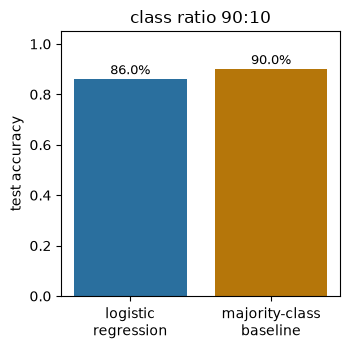

AUC = 0.556  balanced accuracy = 0.478  sensitivity = 0.000  specificity = 0.956
test class counts: 90 control, 10 autism


In [12]:
# Ordinary, editable Python: change class_ratio and random_state and rerun
# to explore the same imbalance/misleading-accuracy demonstration the
# browser activity shows, using real resampled participants and the SAME
# fixed model from Section 3 (C = C_EXAMPLE = 1.0).
class_ratio = "90:10"
random_state = 42

RATIO_TABLE = {
    "50:50": (0.50, 0.50), "60:40": (0.60, 0.40), "70:30": (0.70, 0.30),
    "80:20": (0.80, 0.20), "90:10": (0.90, 0.10), "95:5": (0.95, 0.05),
}
majority_pct, minority_pct = RATIO_TABLE[class_ratio]
cohort_size = 400

rng = np.random.default_rng(20000)  # fixed cohort draw, independent of random_state
majority_idx = np.flatnonzero(y == 0)
minority_idx = np.flatnonzero(y == 1)
n_majority = round(cohort_size * majority_pct)
n_minority = cohort_size - n_majority
chosen = np.concatenate([
    rng.choice(majority_idx, size=n_majority, replace=False),
    rng.choice(minority_idx, size=n_minority, replace=False),
])
X_cohort, y_cohort = X[chosen], y[chosen]
print(f"cohort: {len(y_cohort)} participants ({n_majority} control, {n_minority} autism)")

Xtr, Xte, ytr, yte = train_test_split(
    X_cohort, y_cohort, test_size=0.25, random_state=random_state, stratify=y_cohort
)
imb_model = make_pipeline(StandardScaler(), LogisticRegression(C=C_EXAMPLE, max_iter=5000)).fit(Xtr, ytr)
imb_pred = imb_model.predict(Xte)
imb_proba = imb_model.predict_proba(Xte)[:, list(imb_model.classes_).index(1)]

imb_cm = confusion_matrix(yte, imb_pred, labels=[0, 1])
imb_tn, imb_fp, imb_fn, imb_tp = imb_cm[0, 0], imb_cm[0, 1], imb_cm[1, 0], imb_cm[1, 1]
imb_accuracy = accuracy_score(yte, imb_pred)
imb_sensitivity = imb_tp / (imb_tp + imb_fn) if (imb_tp + imb_fn) else float("nan")
imb_specificity = imb_tn / (imb_tn + imb_fp) if (imb_tn + imb_fp) else float("nan")
imb_balanced_accuracy = (imb_sensitivity + imb_specificity) / 2
imb_auc = roc_auc_score(yte, imb_proba)
n_test_pos = int(yte.sum())
n_test_neg = len(yte) - n_test_pos
imb_baseline = max(n_test_pos, n_test_neg) / len(yte)

fig, ax = plt.subplots(figsize=(3.6, 3.6))
bars = ax.bar(["logistic\nregression", "majority-class\nbaseline"], [imb_accuracy, imb_baseline],
              color=["#2a6f9e", "#b5760a"])
for bar, value in zip(bars, [imb_accuracy, imb_baseline]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("test accuracy")
ax.set_title(f"class ratio {class_ratio}")
plt.tight_layout(); plt.show()

print(f"AUC = {imb_auc:.3f}  balanced accuracy = {imb_balanced_accuracy:.3f}  "
      f"sensitivity = {imb_sensitivity:.3f}  specificity = {imb_specificity:.3f}")
print(f"test class counts: {n_test_neg} control, {n_test_pos} autism")


## In summary

- Logistic regression outputs probabilities before class labels; a decision
  threshold turns a probability into a prediction.
- Fixing `C = 1.0` in advance, fitting on the training participants, and
  evaluating once on a locked test set is the same workflow
  structure Exercise 3 used for `k`. A later lesson introduces systematic
  methods for choosing `C`.
- Testing on participants excluded from fitting -- not on the training
  data -- is what every metric in this notebook does; all of them came
  from the held-out test set.
- A confusion matrix identifies the kinds of correct and incorrect
  decisions a classifier makes.
- Accuracy should be interpreted relative to class balance and an
  appropriate baseline: a classifier that predicts only the majority class
  can score a high accuracy while detecting none of the minority class.
- Confusion-matrix-derived measures -- sensitivity, specificity, balanced
  accuracy -- and AUC can reveal failures hidden by accuracy alone; a
  chosen threshold changes the confusion matrix, never the AUC.


### Questions to take away

**1.** Why is `predict_proba()`, not `predict()`, needed to compute the ROC
curve and AUC?

```{dropdown} Answer
`predict()` only returns the class label already decided at one fixed
threshold (0.50 by default) -- a single point, not a curve. The ROC curve
needs the underlying probability for every participant so the threshold can
be swept across every possible value and a new confusion matrix computed at
each one. `predict_proba()` is what makes that sweep possible; `predict()`
alone would only ever give one (FPR, TPR) point.
```

**2.** What generally happens to false negatives when the decision threshold
is lowered?

```{dropdown} Answer
They generally decrease. A lower threshold predicts the positive class
(autism) more readily, so fewer actually-positive participants are missed
(fewer false negatives) -- at the cost of more false positives, since more
controls are now also predicted positive.
```

**3.** Why can 95% accuracy describe a useless classifier under class
imbalance, and what should you look at instead?

```{dropdown} Answer
At a severe enough class imbalance (e.g. 95:5), predicting the majority
class for everyone reaches 95% accuracy while detecting none of the
minority class. Accuracy alone cannot distinguish that classifier from one
that has genuinely learned to separate the classes. Comparing accuracy to
the majority-class baseline for the same test partition, and inspecting
sensitivity, specificity, balanced accuracy, and AUC, reveals what accuracy
alone conceals.
```
